In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.cm as cm
plt.rc('pdf', fonttype=42)

from sklearn.cluster import HDBSCAN
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

import os
from itertools import combinations

import networkx as nx

In [2]:
### Goal: Compare D12/29 data with MERFISH data

In [3]:
k_val = 100
time_point_list = ["D4","D8","D12","D29"]
output_base_dir = "/project/GCRB/Hon_lab/s223695/Data_project/20241017_TFperturb_CM_timecourse/cNMF_timecourse/processed_data"
top300_df_dict = {key: pd.read_csv(os.path.join(output_base_dir,f"{key}_k{k_val}_top300_genes.csv"),index_col=0) \
                  for key in time_point_list}

regulation_df_dict = {key: pd.read_csv(os.path.join(output_base_dir,f"{key}_k{k_val}_usage_pert.csv"),index_col=0) \
                  for key in time_point_list}

regulation_df_dict_total = regulation_df_dict.copy()
for key in regulation_df_dict_total.keys():
    regulation_df_dict_total[key]["Score Column"] = \
        regulation_df_dict_total[key]["Score Column"].apply(lambda x: f"{key}_{x.split("_")[0]}{x.split("_")[1]}")
    regulation_df_dict_total[key]["time_point"] = key
regulation_df_total = pd.concat(regulation_df_dict_total.values())
regulation_df_total = regulation_df_total.reset_index(drop=True)

In [4]:
regulation_df_total

,Gene,Score Column,Statistic,p-value,Log2 Fold Change,Corrected p-value (BH),dataset,time_point
0,non-targeting (self),D4_Usage1,473488764.5,1.000000e+00,NaN,1.000000e+00,usage_norm_k_100,D4
1,ADNP2:P1P2,D4_Usage1,23736728.5,1.180699e-08,-0.143098,3.093465e-07,usage_norm_k_100,D4
2,AFF4:P1P2,D4_Usage1,28809202.0,8.878805e-01,0.012576,9.718723e-01,usage_norm_k_100,D4
3,AHCY:P1P2,D4_Usage1,28643010.5,7.975510e-01,-0.014176,9.413103e-01,usage_norm_k_100,D4
4,AHDC1:P1P2,D4_Usage1,20633495.5,8.523650e-01,-0.002299,9.616283e-01,usage_norm_k_100,D4
...,...,...,...,...,...,...,...,...
152995,ZNF8:P1P2,D29_Usage100,17665767.5,7.202165e-01,0.023466,9.015844e-01,usage_norm_k_100,D29
152996,ZNF91:P1P2,D29_Usage100,18908247.5,9.038940e-01,-0.550621,9.718778e-01,usage_norm_k_100,D29
152997,ZSCAN10:P1P2,D29_Usage100,11068831.0,2.405324e-01,-0.811801,5.741170e-01,usage_norm_k_100,D29
152998,ZSCAN20:P1P2,D29_Usage100,9777129.0,2.459087e-01,0.027306,5.787498e-01,usage_norm_k_100,D29


In [5]:
top_gene_dict = {}
for key in time_point_list:
    for gp_name in top300_df_dict[key].columns:
        top_gene_dict[f"{key}_Usage{gp_name}"] = top300_df_dict[key].loc[:,gp_name].values[:300]

### Integration with Spatial data

In [6]:
usage_df_path = "/project/GCRB/Hon_lab/s223695/Data_project/20241017_TFperturb_CM_timecourse/spatial_comparison/cNMF_Spatial_MERFISH/result/result.usages.k_50.dt_0_2.consensus.txt"
loading_df_path = "/project/GCRB/Hon_lab/s223695/Data_project/20241017_TFperturb_CM_timecourse/spatial_comparison/cNMF_Spatial_MERFISH/result/result.gene_spectra_score.k_50.dt_0_2.txt"
all_genes_merfish_path = "/project/GCRB/Hon_lab/s223695/Data_project/20241017_TFperturb_CM_timecourse/spatial_comparison/cNMF_Spatial_MERFISH/result/result.overdispersed_genes.txt"

usage_df_merfish = pd.read_csv(usage_df_path,sep="\t",index_col=0)
usage_df_merfish.columns = [f"Usage_{key}" for key in usage_df_merfish.columns]

loading_df_merfish = pd.read_csv(loading_df_path,sep="\t",index_col=0).T

n_top_genes=10
top_genes = []
for gep in loading_df_merfish.columns:
    top_genes.append(list(loading_df_merfish.sort_values(by=gep, ascending=False).index[:n_top_genes]))

top_genes_merfish = pd.DataFrame(top_genes, index=loading_df_merfish.columns).T

all_genes_merfish=pd.read_csv(all_genes_merfish_path,header=None).values.flatten()


In [7]:
all_genes_merfish.shape

(238,)

In [8]:
top_genes_merfish

,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
0,HEY2,IRX3,TNNT1,DKK3,COL2A1,PCNA,SCN7A,COL9A2,KPNA2,COL15A1,...,RSPO3,SLC26A7,TLL2,AGPS,TFPI2,TNFSF14,IL1B,ELAVL2,HAPLN1,SHISA3
1,CKMT2,SCN5A,CACNA1C,PAM,ADAMTS8,MYBL2,NKD2,PENK,PLK1,CA4,...,BMP2,JAG1,DES,NPR3,UPK3B,ITLN1,PTPRC,HHIP,VCAN,CBLN2
2,LBH,IRX4,SLC1A3,ANGPT1,DAPK2,UHRF1,TCF21,FMOD,KIF20A,CD34,...,VCAN,FBLN2,RRAD,POSTN,HHIP,SOX9,MYH7,SBSPON,NSG1,LEPR
3,FZD1,GJA1,TTN,C1QTNF3,MYH6,MCM7,GAS7,NELL2,TOP2A,CD36,...,TBX3,CPE,HHIP,PLK2,FLRT2,SULF1,CNN1,PRPH,RGS5,KLF4
4,GJA1,RAMP1,RABGAP1L,TECRL,GJA5,RRM2,DCN,VCAN,MKI67,CAV1,...,DPYSL3,CGNL1,SCN7A,DLK1,NRP2,UPK3B,DES,TNNT1,APOE,PROX1
5,LMOD3,MYH7,RYR2,PRSS35,PAM,CLSPN,SPON2,PRRX1,ARL6IP1,ARHGAP18,...,BAMBI,GJA5,ALDH1A2,PLN,COTL1,COTL1,TFF3,NRP2,FRZB,DLK1
6,PLN,NKX2-5,PPP1R12B,TBX5,TBX5,CDT1,HHIP,BAMBI,PTTG1,ARHGAP29,...,NELL2,MCAM,PITX2,CBLN2,RPRM,MPZ,CTSV,IGFBP5,MAZ,KLF2
7,DES,PPP1R12B,NAV1,NR2F1,PPM1K,RMI2,OAF,TPBG,MAZ,KLF2,...,FBLN2,MEF2C,FNDC1,FN1,CD9,DLK1,TMEM40,ISL1,DKK3,ADGRL2
8,MYH7,HAND1,CD24,BTG1,SFRP1,MKI67,SOX9,DPYSL3,RRM2,RBP1,...,NTS,FOXC1,CPE,RND3,IGFBP4,SPON2,LBH,TBX18,HEY2,MAF
9,CASQ2,LBH,TECRL,GJA5,TTN,CNN1,PDGFRA,RASL11B,MYBL2,IGFBP4,...,RGS5,POSTN,LBH,ADGRL2,ADGRL2,CNN1,FOXS1,ALDH1A2,GJA5,SOX9


In [9]:
top_genes_merfish.loc[:,22]

0      ITLN1
1      SULF1
2    ALDH1A2
3     SBSPON
4       INMT
5      UPK3B
6     IGFBP5
7        WT1
8     ENTPD2
9      TBX18
Name: 22, dtype: object

In [10]:
top_gene_dict_merfish = {}
for gp_name in top_genes_merfish.columns:
        top_gene_dict_merfish[f"MERFISH_Usage{gp_name}"] = top_genes_merfish.loc[:,gp_name].values[:10]

### Check rank in scRNA-Seq

In [11]:
gp_anno = {
    "MERFISH_Usage1":"Ventricle-Working",
    "MERFISH_Usage2":"Ventricle-Trabular",
    "MERFISH_Usage3":"Cardiomyocytes",
    "MERFISH_Usage4":"Atrial_1",
    "MERFISH_Usage5":"Atrial_2",
    "MERFISH_Usage18":"Endothelial",
    "MERFISH_Usage22":"Epicardial"
}

In [12]:
Marker_dict = {"Ventricle_working":["HEY2","CKMT2"],
               "Ventricle_trabecular":["IRX3","SCN5A"],
               "Atrial":["COL2A1","ADAMTS8"]
              }

marker_genes = np.concatenate(list(Marker_dict.values()))

In [13]:
overlap_res = []

for key, target_genes in Marker_dict.items():    
    for target_gene in target_genes:
        for key_gp,gene_list in top_gene_dict.items():
            if target_gene in gene_list:
                rank = np.where(gene_list==target_gene)[0][0]
            else:
                rank = np.nan
            overlap_res.append([key_gp,target_gene,rank])

overlap_res_df = pd.DataFrame(overlap_res,columns=["GP_name","Marker_gene","rank"]).pivot(index="GP_name",columns="Marker_gene",values="rank")
is_sig_flag = \
    (overlap_res_df[Marker_dict["Ventricle_working"]].isna().sum(axis=1)==0) | \
    (overlap_res_df[Marker_dict["Ventricle_trabecular"]].isna().sum(axis=1)==0) | \
    (overlap_res_df[Marker_dict["Atrial"]].isna().sum(axis=1)==0)

overlap_res_df_sig = overlap_res_df.loc[is_sig_flag,marker_genes].copy().fillna(300)

In [14]:
overlap_res_df_sig

Marker_gene,HEY2,CKMT2,IRX3,SCN5A,COL2A1,ADAMTS8
GP_name,,,,,,
D12_Usage16,300.0,300.0,165.0,42.0,93.0,300.0
D29_Usage12,300.0,300.0,71.0,152.0,300.0,300.0
D29_Usage22,144.0,51.0,300.0,300.0,300.0,300.0
D29_Usage24,300.0,300.0,300.0,300.0,192.0,129.0
D29_Usage25,300.0,300.0,8.0,253.0,300.0,300.0
D4_Usage36,300.0,300.0,129.0,193.0,300.0,300.0


In [15]:
overlap_res_df_sig = overlap_res_df.loc[overlap_res_df.isna().sum(axis=1)<5,marker_genes].copy()

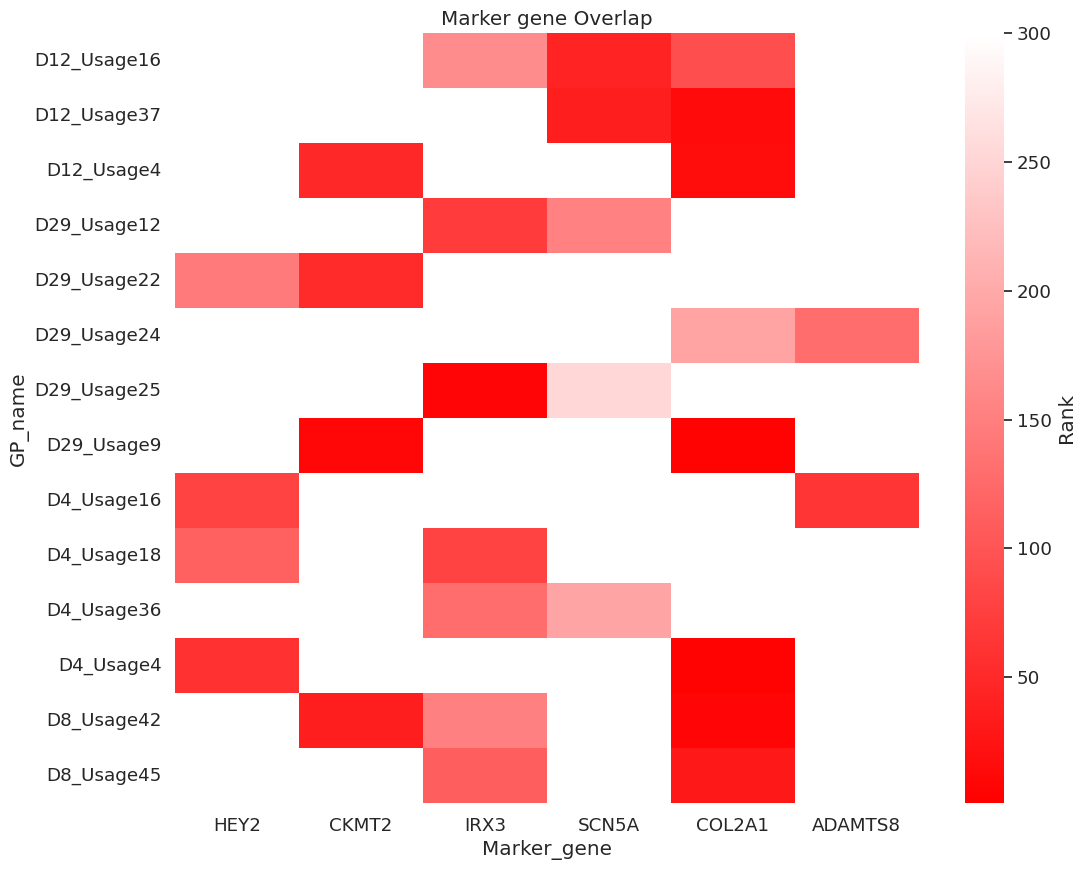

In [16]:
#Plotting
cmap = sns.blend_palette(["red", "white"], as_cmap=True)

sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(12, 10))
ax = sns.heatmap(
    overlap_res_df_sig,
    cmap=cmap,
    vmin=1,
    vmax=300,
    linewidths=0.0,
    linecolor="white",
    cbar_kws={"label": "Rank"}
)
ax.set_title("Marker gene Overlap")
plt.show()

In [17]:
in_vivo_gp_list = ["MERFISH_Usage1","MERFISH_Usage2","MERFISH_Usage5"]
in_vitro_gp_list = ["D29_Usage22","D29_Usage25","D29_Usage24"]

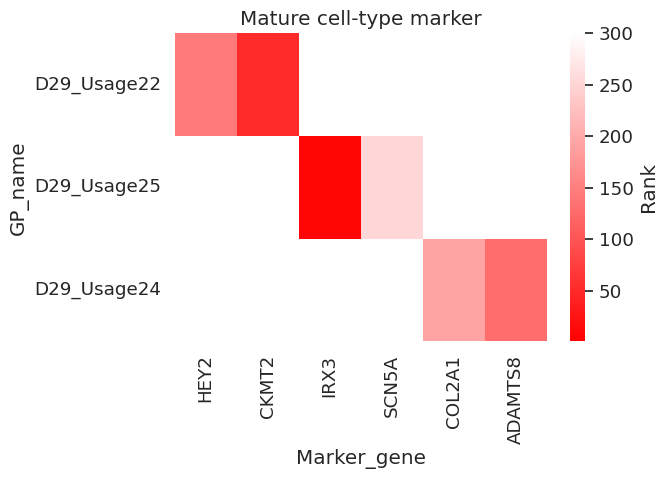

In [18]:
overlap_res_df_sig_show = overlap_res_df_sig.loc[in_vitro_gp_list,marker_genes]

#Plotting
cmap = sns.blend_palette(["red", "white"], as_cmap=True)

sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    overlap_res_df_sig_show,
    cmap=cmap,
    vmin=1,
    vmax=300,
    linewidths=0.0,
    linecolor="white",
    cbar_kws={"label": "Rank"}
)
ax.set_title("Mature cell-type marker")
plt.savefig("../figure/marker_gene_rank.pdf")
plt.show()

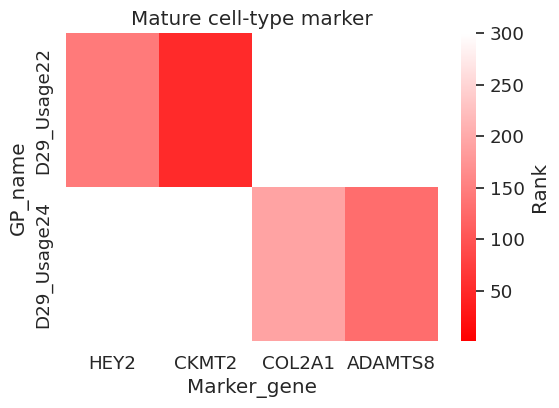

In [19]:
marker_genes_select = ["HEY2","CKMT2","COL2A1","ADAMTS8"]
in_vitro_gp_list_select = ["D29_Usage22","D29_Usage24"]

overlap_res_df_sig_show_select = \
    overlap_res_df_sig_show.loc[in_vitro_gp_list_select,marker_genes_select]

#Plotting
cmap = sns.blend_palette(["red", "white"], as_cmap=True)

sns.set_theme(style="white", font_scale=1.2)

plt.figure(figsize=(6, 4))
ax = sns.heatmap(
    overlap_res_df_sig_show_select,
    cmap=cmap,
    vmin=1,
    vmax=300,
    linewidths=0.0,
    linecolor="white",
    cbar_kws={"label": "Rank"}
)
ax.set_title("Mature cell-type marker")
plt.savefig("../figure/marker_gene_rank_select.pdf")
plt.show()

### Regulator of the Atrial/Ventricle Program

In [20]:
regulation_df_total_D29 = regulation_df_total[regulation_df_total["time_point"]=="D29"]

In [21]:
gp_annotation_dict = {
    "Vent-Working": "D29_Usage22",
    "Vent-Trabular": "D29_Usage25",
    "Atrial":      "D29_Usage24"
}

# gp_annotation_dict = {
#     "totalCM":     "D29_Usage6",
#     "Ventricular": "D29_Usage2",
#     "Atrial":      "D29_Usage15",
#     "Endothelial": "D29_Usage47",
#     "Epicardial":  "D29_Usage23"
# }

In [22]:
target_col = ["Gene","Log2 Fold Change","Corrected p-value (BH)"]
gp_reg_dict = {key: regulation_df_total_D29.loc[regulation_df_total_D29["Score Column"]==item,target_col] \
               for key,item in gp_annotation_dict.items()}
for key in gp_reg_dict.keys():
    gp_reg_dict[key].columns = ["Gene",f"Log2 Fold Change_{key}",f"Corrected p-value (BH)_{key}"]
    gp_reg_dict[key] = gp_reg_dict[key].set_index("Gene")

In [23]:
merge_gp_reg_df = pd.concat(gp_reg_dict.values(),axis=1)

In [24]:
merge_gp_reg_df.to_csv("../data/gp_regulation_invivo_gp.csv")

#### Show in heatmap

In [25]:
merge_gp_reg_df

,Log2 Fold Change_Vent-Working,Corrected p-value (BH)_Vent-Working,Log2 Fold Change_Vent-Trabular,Corrected p-value (BH)_Vent-Trabular,Log2 Fold Change_Atrial,Corrected p-value (BH)_Atrial
Gene,,,,,,
non-targeting (self),NaN,1.000000,NaN,1.000000e+00,NaN,1.000000e+00
ADNP2:P1P2,0.062946,0.101594,0.312000,1.704949e-08,0.591915,2.937389e-12
AFF4:P1P2,-0.169407,0.275206,0.243946,3.090115e-02,0.012337,8.107653e-01
AHCY:P1P2,-0.009645,0.921231,0.028576,9.145059e-01,-0.272566,1.371724e-02
AHDC1:P1P2,0.277248,0.000005,0.207103,3.178995e-02,0.971012,9.084952e-20
...,...,...,...,...,...,...
ZNF8:P1P2,-0.100222,0.139518,0.008013,6.206362e-01,-0.085554,3.273610e-01
ZNF91:P1P2,-0.072137,0.286132,0.310958,3.014635e-10,-0.002298,7.526896e-01
ZSCAN10:P1P2,-0.199326,0.045222,0.620915,5.413747e-22,0.507616,1.815748e-15


In [26]:
merge_gp_fc_df = merge_gp_reg_df.loc[:,["Log2 Fold Change_Vent-Working",
                                        "Log2 Fold Change_Vent-Trabular",
                                        "Log2 Fold Change_Atrial"]].copy()
merge_gp_fdr_df = merge_gp_reg_df.loc[:,["Corrected p-value (BH)_Vent-Working",
                                         "Corrected p-value (BH)_Vent-Trabular",
                                         "Corrected p-value (BH)_Atrial"]].copy()

In [27]:
sig_mask = merge_gp_fdr_df.values<0.01

In [28]:
merge_gp_fc_df_sig = merge_gp_fc_df.where(sig_mask,np.nan).dropna(axis=0,how="all").fillna(0)

/tmp/ipykernel_3030190/3078443112.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("RdBu_r").copy()


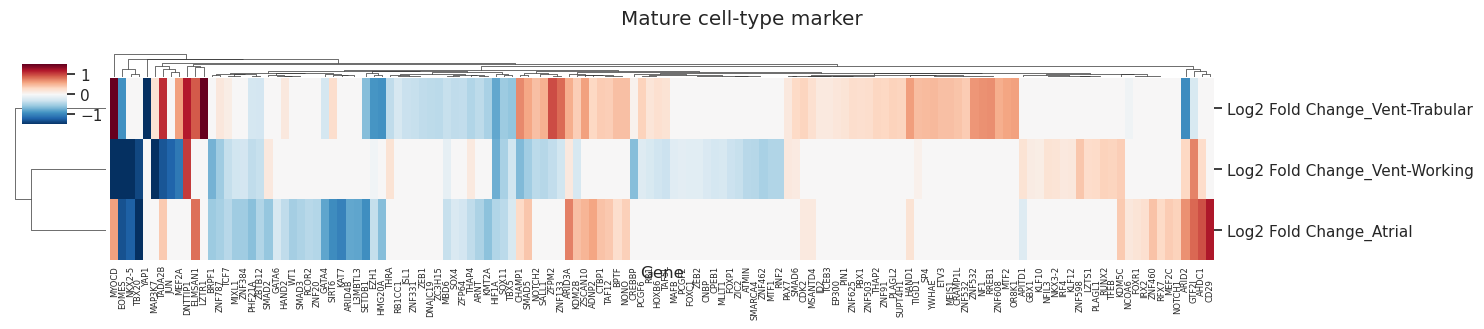

In [29]:
# Transpose the dataframe to swap rows and columns
merge_gp_fc_df_sig_t = merge_gp_fc_df_sig.T

# Plotting
cmap = cm.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")  # Color for NaN

sns.set_theme(style="white", font_scale=1.0)

g = sns.clustermap(
    merge_gp_fc_df_sig_t,
    cmap=cmap,
    vmin=-1.5,
    vmax=1.5,
    linewidths=0.0,
    linecolor="white",
    figsize=(15, 5),               # Swapped from (5, 28) to (28, 5)
    dendrogram_ratio=(0.08, 0.12), # Swapped the ratios to match new dimensions
    cbar_pos=(0.02, 0.82, 0.03, 0.12), # You may need to adjust this depending on the new layout
)
ax = g.ax_heatmap
# Title
g.fig.suptitle("Mature cell-type marker", y=1.05)

# Use all labels in clustered order
labels = g.data2d.columns
xpos = np.arange(len(labels)) + 0.5

# Remove default tick labels
ax.set_xticks([])
ax.tick_params(axis="x", length=0)

# Draw all labels manually in two rows
for i, (x, lab) in enumerate(zip(xpos, labels)):
    lab=lab.split(":")[0]
    y = -0.03 if i % 2 == 0 else -0.10
    ax.text(
        x, y, lab,
        rotation=90,
        ha="center",
        va="top",
        fontsize=6,
        transform=ax.get_xaxis_transform(),
        clip_on=False
    )
plt.savefig("../figure/clustermap_CM_sub.pdf")
plt.show()

#### Vent-working vs Vent-Trabular

In [30]:
target_col = ["Log2 Fold Change_Vent-Working","Log2 Fold Change_Vent-Trabular"]

w_up_t_up_pert = \
    merge_gp_fc_df_sig[(merge_gp_fc_df_sig["Log2 Fold Change_Vent-Working"]>0) & \
                       (merge_gp_fc_df_sig["Log2 Fold Change_Vent-Trabular"]>0)].index.tolist()
w_up_t_down_pert = \
    merge_gp_fc_df_sig[(merge_gp_fc_df_sig["Log2 Fold Change_Vent-Working"]>0) & \
                       (merge_gp_fc_df_sig["Log2 Fold Change_Vent-Trabular"]<0)].index.tolist()
w_down_t_up_pert = \
    merge_gp_fc_df_sig[(merge_gp_fc_df_sig["Log2 Fold Change_Vent-Working"]<0) & \
                       (merge_gp_fc_df_sig["Log2 Fold Change_Vent-Trabular"]>0)].index.tolist()
w_down_t_down_pert = \
    merge_gp_fc_df_sig[(merge_gp_fc_df_sig["Log2 Fold Change_Vent-Working"]<0) & \
                       (merge_gp_fc_df_sig["Log2 Fold Change_Vent-Trabular"]<0)].index.tolist()

gene_arr_list = w_up_t_up_pert + w_down_t_down_pert + w_up_t_down_pert + w_down_t_up_pert
merge_gp_fc_df_sig_vent_sub = \
    merge_gp_fc_df_sig.loc[gene_arr_list,target_col]

/tmp/ipykernel_3030190/3013668485.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("RdBu_r").copy()


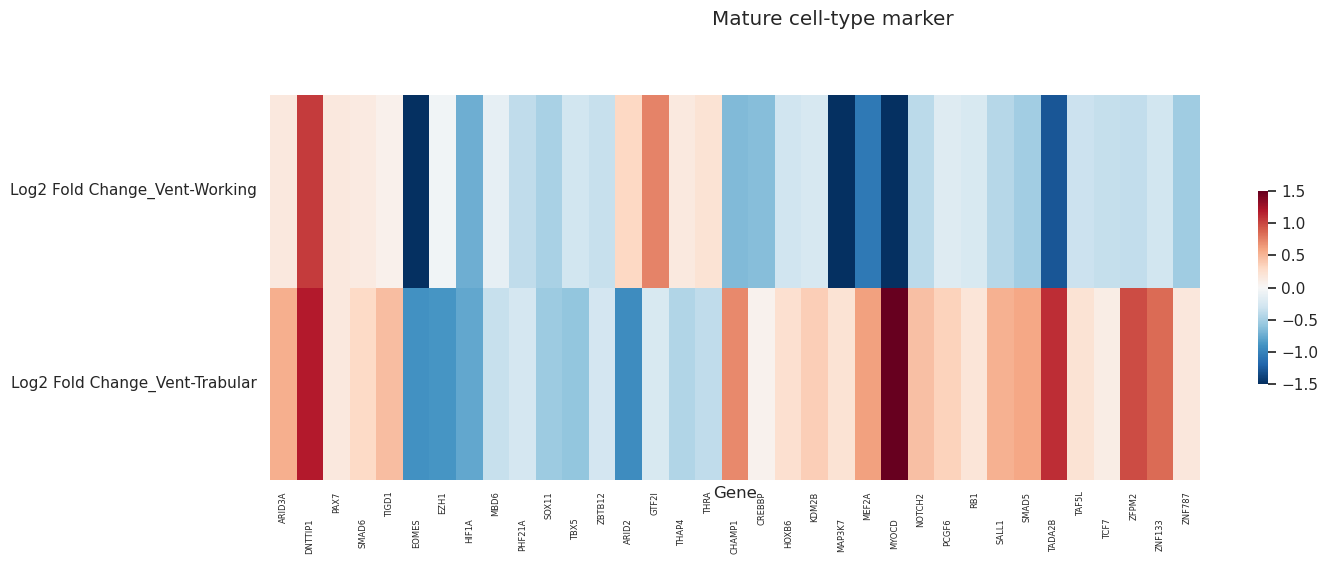

In [31]:
# Ventricle Working vs Trabecular

# Plotting
cmap = cm.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")  # Color for NaN

sns.set_theme(style="white", font_scale=1.0)

fig, ax = plt.subplots(figsize=(15, 5))

sns.heatmap(
    merge_gp_fc_df_sig_vent_sub.T,
    cmap=cmap,
    vmin=-1.5,
    vmax=1.5,
    linewidths=0.0,
    linecolor="white",
    cbar_kws={"shrink": 0.5},
    ax=ax,
)

# Title
fig.suptitle("Mature cell-type marker", y=1.05)

# Use all labels in original order
labels = merge_gp_fc_df_sig_vent_sub.T.columns
xpos = np.arange(len(labels)) + 0.5

# Remove default tick labels
ax.set_xticks([])
ax.tick_params(axis="x", length=0)

# Draw all labels manually in two rows
for i, (x, lab) in enumerate(zip(xpos, labels)):
    lab = lab.split(":")[0]
    y = -0.03 if i % 2 == 0 else -0.10
    ax.text(
        x, y, lab,
        rotation=90,
        ha="center",
        va="top",
        fontsize=6,
        transform=ax.get_xaxis_transform(),
        clip_on=False
    )

plt.savefig("../figure/heatmap_CM_vent_sub.pdf", bbox_inches="tight")
plt.show()

#### Vent-working vs Atrial

In [32]:
target_col = ["Log2 Fold Change_Vent-Working","Log2 Fold Change_Atrial"]

v_up_a_up_pert = \
    merge_gp_fc_df_sig[(merge_gp_fc_df_sig["Log2 Fold Change_Vent-Working"]>0) & \
                       (merge_gp_fc_df_sig["Log2 Fold Change_Atrial"]>0)].index.tolist()
v_up_a_down_pert = \
    merge_gp_fc_df_sig[(merge_gp_fc_df_sig["Log2 Fold Change_Vent-Working"]>0) & \
                       (merge_gp_fc_df_sig["Log2 Fold Change_Atrial"]<0)].index.tolist()
v_down_a_up_pert = \
    merge_gp_fc_df_sig[(merge_gp_fc_df_sig["Log2 Fold Change_Vent-Working"]<0) & \
                       (merge_gp_fc_df_sig["Log2 Fold Change_Atrial"]>0)].index.tolist()
v_down_a_down_pert = \
    merge_gp_fc_df_sig[(merge_gp_fc_df_sig["Log2 Fold Change_Vent-Working"]<0) & \
                       (merge_gp_fc_df_sig["Log2 Fold Change_Atrial"]<0)].index.tolist()

gene_arr_list = v_up_a_up_pert + v_down_a_down_pert + v_up_a_down_pert + v_down_a_up_pert
merge_gp_fc_df_sig_vent_atr = \
    merge_gp_fc_df_sig.loc[gene_arr_list,target_col]

/tmp/ipykernel_3030190/1418350050.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("RdBu_r").copy()


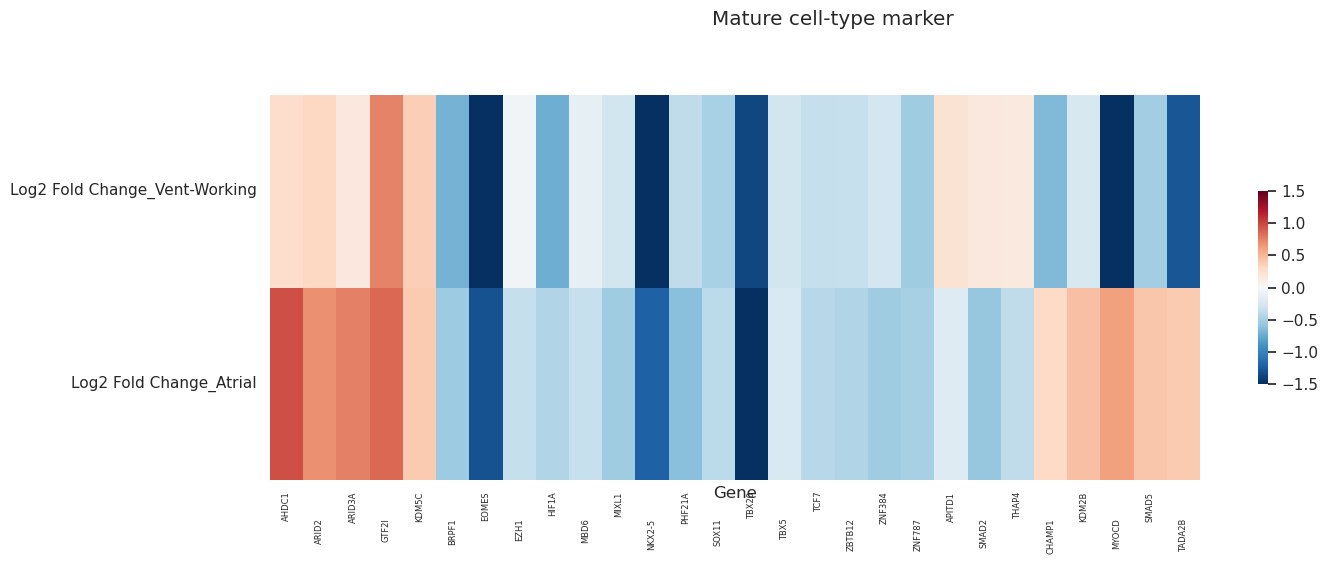

In [33]:
# Ventricle Working vs Trabecular

# Plotting
cmap = cm.get_cmap("RdBu_r").copy()
cmap.set_bad("lightgray")  # Color for NaN

sns.set_theme(style="white", font_scale=1.0)

fig, ax = plt.subplots(figsize=(15, 5))

sns.heatmap(
    merge_gp_fc_df_sig_vent_atr.T,
    cmap=cmap,
    vmin=-1.5,
    vmax=1.5,
    linewidths=0.0,
    linecolor="white",
    cbar_kws={"shrink": 0.5},
    ax=ax,
)

# Title
fig.suptitle("Mature cell-type marker", y=1.05)

# Use all labels in original order
labels = merge_gp_fc_df_sig_vent_atr.T.columns
xpos = np.arange(len(labels)) + 0.5

# Remove default tick labels
ax.set_xticks([])
ax.tick_params(axis="x", length=0)

# Draw all labels manually in two rows
for i, (x, lab) in enumerate(zip(xpos, labels)):
    lab = lab.split(":")[0]
    y = -0.03 if i % 2 == 0 else -0.10
    ax.text(
        x, y, lab,
        rotation=90,
        ha="center",
        va="top",
        fontsize=6,
        transform=ax.get_xaxis_transform(),
        clip_on=False
    )

plt.savefig("../figure/heatmap_CM_vent_atr.pdf", bbox_inches="tight")
plt.show()

#### Show in scatterplot

=== Vent-Working vs Vent-Trabular ===
total points: 386
out of x range (-2.5 to 2.5): 1
out of y range (-2.5 to 2.5): 2
out of either x or y range: 3
significance
not_sig                   265
Vent-Trabular_only_sig     51
Vent-Working_only_sig      35
both_sig                   35
Name: count, dtype: int64



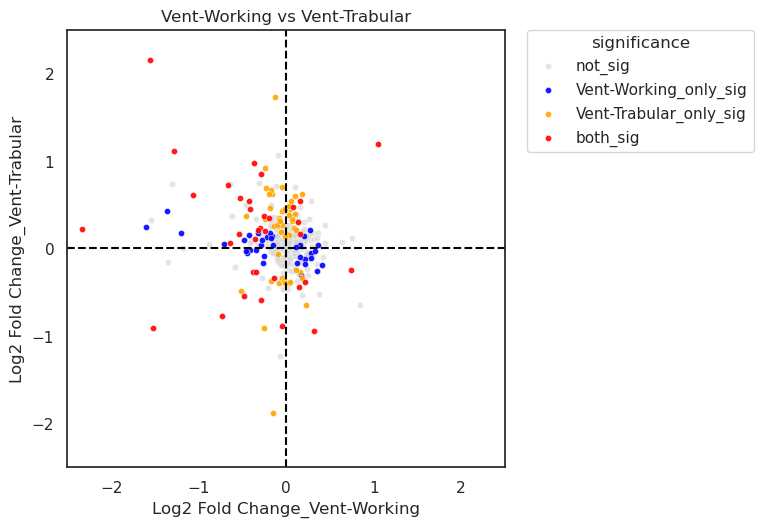

=== Vent-Working vs Atrial ===
total points: 386
out of x range (-2.5 to 2.5): 1
out of y range (-2.5 to 2.5): 2
out of either x or y range: 3
significance
not_sig                  281
Vent-Working_only_sig     42
Atrial_only_sig           35
both_sig                  28
Name: count, dtype: int64



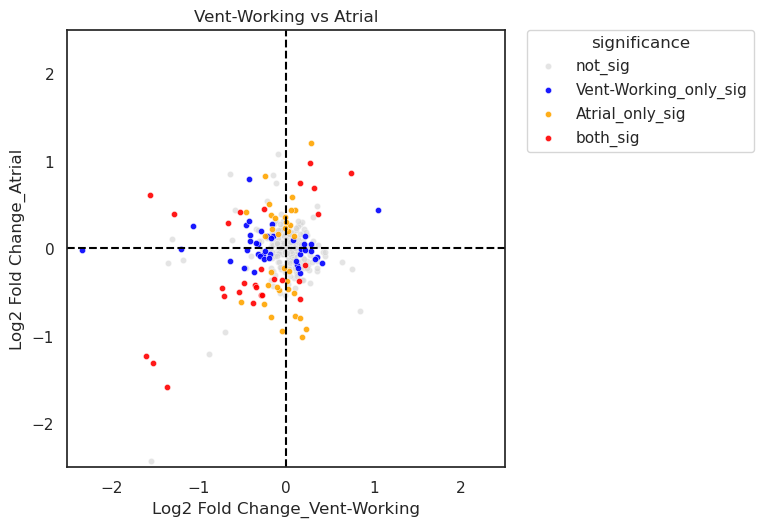

=== Vent-Trabular vs Atrial ===
total points: 386
out of x range (-2.5 to 2.5): 2
out of y range (-2.5 to 2.5): 2
out of either x or y range: 3
significance
not_sig                   276
Vent-Trabular_only_sig     47
both_sig                   39
Atrial_only_sig            24
Name: count, dtype: int64



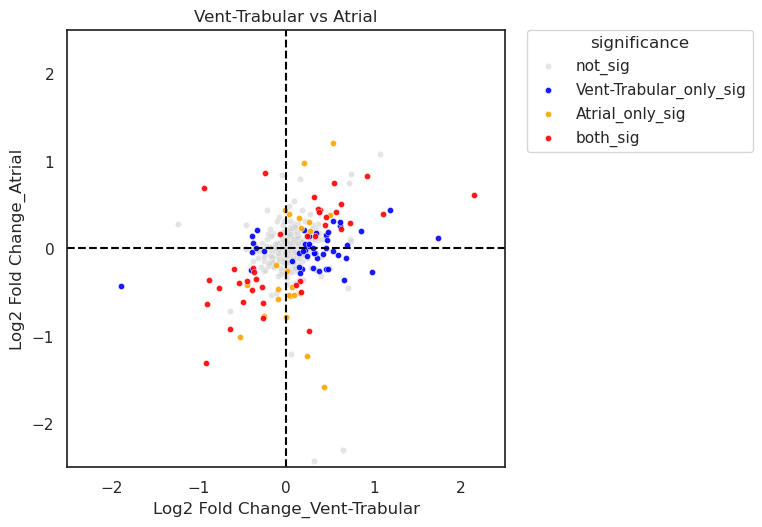

In [34]:
lineage_combis = list(combinations(gp_annotation_dict.keys(), 2))
fdr_cut_off_vis = 0.01

sig_reg_df_dict = {}

x_min, x_max = -2.5, 2.5
y_min, y_max = -2.5, 2.5

for gp1, gp2 in lineage_combis:
    target_gp_reg_df = merge_gp_reg_df.loc[:, [
        f"Log2 Fold Change_{gp1}", f"Corrected p-value (BH)_{gp1}",
        f"Log2 Fold Change_{gp2}", f"Corrected p-value (BH)_{gp2}"
    ]].copy()

    x_col = f"Log2 Fold Change_{gp1}"
    y_col = f"Log2 Fold Change_{gp2}"
    p1_col = f"Corrected p-value (BH)_{gp1}"
    p2_col = f"Corrected p-value (BH)_{gp2}"

    # Determine significance in each group
    sig1 = target_gp_reg_df[p1_col] < fdr_cut_off_vis
    sig2 = target_gp_reg_df[p2_col] < fdr_cut_off_vis

    # Store rows significant in both groups
    target_gp_reg_df["is_sig_both"] = sig1 & sig2
    sig_reg_df_dict[f"{gp1}_{gp2}"] = target_gp_reg_df[target_gp_reg_df["is_sig_both"]].copy()

    # Classify points by significance pattern
    target_gp_reg_df["significance"] = "not_sig"
    target_gp_reg_df.loc[sig1 & sig2, "significance"] = "both_sig"
    target_gp_reg_df.loc[sig1 & (~sig2), "significance"] = f"{gp1}_only_sig"
    target_gp_reg_df.loc[(~sig1) & sig2, "significance"] = f"{gp2}_only_sig"

    # Count points outside plotting range
    out_of_range_x = (target_gp_reg_df[x_col] < x_min) | (target_gp_reg_df[x_col] > x_max)
    out_of_range_y = (target_gp_reg_df[y_col] < y_min) | (target_gp_reg_df[y_col] > y_max)
    out_of_range_any = out_of_range_x | out_of_range_y

    n_total = len(target_gp_reg_df)
    n_out_x = out_of_range_x.sum()
    n_out_y = out_of_range_y.sum()
    n_out_any = out_of_range_any.sum()

    print(f"=== {gp1} vs {gp2} ===")
    print(f"total points: {n_total}")
    print(f"out of x range ({x_min} to {x_max}): {n_out_x}")
    print(f"out of y range ({y_min} to {y_max}): {n_out_y}")
    print(f"out of either x or y range: {n_out_any}")
    print(target_gp_reg_df["significance"].value_counts())
    print()

    # Split data by category to control drawing order
    df_not_sig = target_gp_reg_df[target_gp_reg_df["significance"] == "not_sig"]
    df_gp1_only = target_gp_reg_df[target_gp_reg_df["significance"] == f"{gp1}_only_sig"]
    df_gp2_only = target_gp_reg_df[target_gp_reg_df["significance"] == f"{gp2}_only_sig"]
    df_both_sig = target_gp_reg_df[target_gp_reg_df["significance"] == "both_sig"]

    # Visualization
    fig, ax = plt.subplots(figsize=(7, 6))

    # Draw gray points first
    sns.scatterplot(
        data=df_not_sig,
        x=x_col,
        y=y_col,
        color="lightgray",
        alpha=0.6,
        s=20,
        label="not_sig",
        ax=ax
    )

    # Draw colored points on top
    sns.scatterplot(
        data=df_gp1_only,
        x=x_col,
        y=y_col,
        color="blue",
        alpha=0.9,
        s=20,
        label=f"{gp1}_only_sig",
        ax=ax
    )

    sns.scatterplot(
        data=df_gp2_only,
        x=x_col,
        y=y_col,
        color="orange",
        alpha=0.9,
        s=20,
        label=f"{gp2}_only_sig",
        ax=ax
    )

    sns.scatterplot(
        data=df_both_sig,
        x=x_col,
        y=y_col,
        color="red",
        alpha=0.9,
        s=20,
        label="both_sig",
        ax=ax
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Keep 1:1 scale inside the scatter plot
    ax.set_aspect("equal", adjustable="box")

    ax.axvline(0, c="black", linestyle="--")
    ax.axhline(0, c="black", linestyle="--")
    ax.set_title(f"{gp1} vs {gp2}")

    # Place legend outside the plot
    ax.legend(
        title="significance",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.subplots_adjust(right=0.75)
    plt.show()